<a href="https://colab.research.google.com/github/Kshitiz-hub-ops/part-3-nlp-sequence-modeling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1500, 6)

Columns: Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

Number of records: 1500

Target Classes:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample Text Records:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object

Average text length: 12.722666666666667


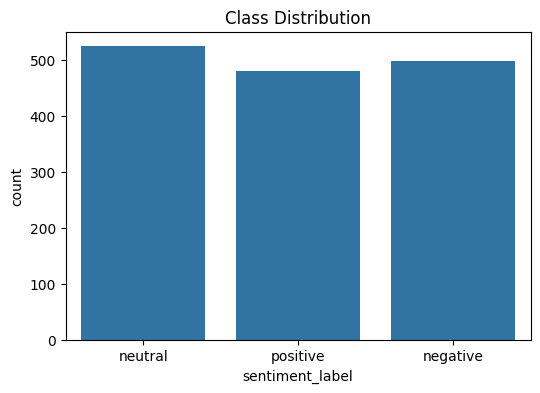

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_support_text_classification.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)

# Number of records
print("\nNumber of records:", len(df))

# Target labels
print("\nTarget Classes:")
print(df['sentiment_label'].value_counts())

# Sample text records
print("\nSample Text Records:")
print(df['customer_message'].head(5))

# Average text length
df['text_length'] = df['customer_message'].apply(lambda x: len(str(x).split()))
print("\nAverage text length:", df['text_length'].mean())

# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment_label', data=df)
plt.title('Class Distribution')
plt.savefig('results/model_evaluation.png')
plt.show()

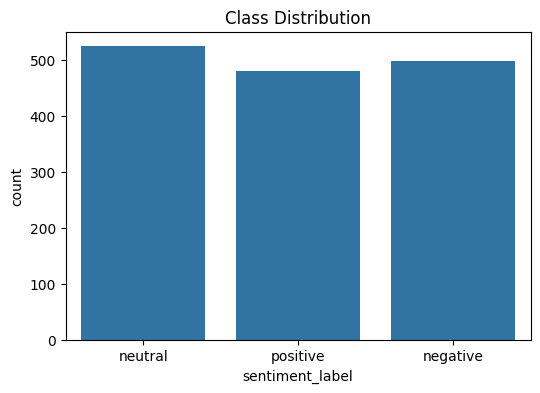

In [2]:
import os
os.makedirs('results', exist_ok=True)

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment_label', data=df)
plt.title('Class Distribution')
plt.savefig('results/model_evaluation.png')
plt.show()

Dataset contains 1500 customer support text records.

Target classes:
- Positive
- Negative
- Neutral

Average text length is approximately 13 words.

Class distribution:
- Neutral: 524
- Negative: 497
- Positive: 479

The dataset is reasonably balanced, making it suitable for text classification tasks.

In [4]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Text cleaning function
def clean_text(text):
    text = str(text).lower()                      # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)      # remove special chars
    return text

# Apply cleaning
df['clean_text'] = df['customer_message'].apply(clean_text)

# Sample cleaned text
print(df[['customer_message', 'clean_text']].head())

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Padding
X = pad_sequences(sequences, maxlen=20)

print("Shape after padding:", X.shape)

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  i need information about the payment process m...  
1       i need information about the payment process  
2  the refund process was fast and convenient i a...  
3  my refund is still pending and this experience...  
4    please tell me how to update my account details  
Shape after padding: (1500, 20)


Task 2: Text Preprocessing

The text data was preprocessed before model training.

Steps performed:

1. Converted all text to lowercase for consistency.
2. Removed unnecessary symbols and special characters.
3. Tokenized the cleaned text into numerical sequences.
4. Applied padding so all text sequences have equal length.

This preprocessing helps prepare the dataset for NLP model training.

In [5]:
print("Sample tokenized sequence:")
print(sequences[0])

print("\nPadded sequence:")
print(X[0])

Sample tokenized sequence:
[4, 29, 136, 39, 1, 90, 33, 3, 6, 7, 2, 10, 12, 8, 13, 8, 14]

Padded sequence:
[  0   0   0   4  29 136  39   1  90  33   3   6   7   2  10  12   8  13
   8  14]


Task 3: Text Vectorization

For text vectorization, tokenizer-based sequences were used.

In this approach, each word is converted into a numerical index, and the full text message becomes a sequence of numbers. Padding was then applied so all sequences have the same length.

Example:
"please update my account details"

may become:

[12, 45, 8, 67]

Why text must be converted into vectors:
Machine learning and deep learning models cannot understand raw text directly because they only work with numerical data.

Text vectorization converts words into numbers so the model can process patterns, relationships, and meaning from the input text.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Features and labels
X = df['clean_text']
y = df['sentiment_label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Model
model = LogisticRegression()
model.fit(X_train_vec, y_train)

# Predictions
y_pred = model.predict(X_test_vec)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



Task 4: Baseline Model

A baseline text classification model was built using Logistic Regression with TF-IDF vectorization.

TF-IDF converts text into numerical vectors based on word importance, and Logistic Regression is a simple but effective classification algorithm for NLP tasks.

Evaluation metrics used:
- Accuracy
- Precision
- Recall
- F1-score

This baseline model provides a reference performance for comparison with more advanced sequence models.

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

# Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(df['sentiment_label'])
y = to_categorical(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LSTM Model
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=20),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Task 5: Sequence Model Architecture

A simple LSTM-based sequence model was designed for sentiment classification.

Architecture:

1. Input Sequence
Customer text messages are converted into tokenized numerical sequences with fixed length padding.

2. Embedding Layer
The embedding layer converts word indices into dense vector representations so the model can learn semantic relationships between words.

3. LSTM Layer
The LSTM layer processes the text sequence while remembering important context from previous words. This makes it suitable for NLP tasks.

4. Output Layer
A softmax output layer predicts one of the sentiment classes:
- Positive
- Negative
- Neutral

Loss Function:
Categorical Crossentropy

Evaluation Metric:
Accuracy

This sequence model is more advanced than the baseline model because it captures word order and contextual information.

Task 6: Attention and Transformer Reflection

1. Why RNNs struggle with long-term dependencies


RNNs process text word by word, but they often forget information from earlier words when the sequence becomes long. This happens because information gets weaker as it passes through many steps.

2. How LSTMs help with memory


LSTMs improve on RNNs by using memory cells and gates. These help the model decide what information to keep, forget, or pass forward. Because of this, LSTMs handle long text sequences better.

3. What attention solves in sequence-to-sequence tasks


Attention helps the model focus on the most relevant words instead of depending only on previous hidden states. This improves performance in tasks like translation, summarization, and text generation.

4. Why transformers are important in modern NLP and Generative AI


Transformers use attention mechanisms to process the full text in parallel instead of one word at a time. This makes training faster and improves performance.

Modern AI models like ChatGPT, BERT, and other generative AI systems are based on transformer architecture because they understand context much better than traditional RNN models.